# Bias-Corrected Holt-Winters Model and Final Validation

## Purpose
Corrects the systematic prediction bias identified in the training walk-forward residuals, finalises the **Holt-Winters (additive trend, damped, additive seasonal)** model, and evaluates it against the held-out validation set. The fitted model and bias constant are persisted to disk for production use.

The bias is estimated as the mean of the training residuals and added to every forecast. The ACF and PACF of the corrected residuals are then inspected to confirm no autocorrelation structure remains.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)
- `data/validation.csv` — Held-out validation set (12 observations, never seen during development)

## Outputs
- `models/hw_model.pkl` — Serialised `ExponentialSmoothing` results object (final fit on full training history)
- `models/hw_bias.npy` — NumPy array containing the scalar bias correction constant
- Inline: training RMSE, corrected residual statistics, ACF/PACF plots, and final validation RMSE with a plot of predictions vs actuals

In [1]:
import pandas as pd
import numpy as np
import pickle
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Fit Validity Guard

In [2]:
def is_hw_fit_valid(fit):
    """Return True if all smoothing params are finite and within [0, 1].

    ExponentialSmoothing does not expose mle_retvals like ARIMA; checking
    that the estimated smoothing weights are bounded is the equivalent
    empirical guard against a failed/degenerate optimisation.

    Bounds are closed [0, 1]: a value of exactly 0 for smoothing_trend is
    valid — it means the optimiser found no per-step trend update is needed.
    The true failure signals are NaN, inf, or values outside [0, 1].
    """
    param_keys = ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal']
    for key in param_keys:
        val = fit.params.get(key)
        if val is None:
            continue
        if not np.isfinite(val) or not (0.0 <= val <= 1.0):
            return False
    return True

## Load Training Data

In [3]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Train / Test Split

In [4]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Walk-Forward Validation with Bias Correction

The bias constant is derived as the mean of the training residuals computed in this walk-forward pass and applied to every subsequent forecast. The model configuration — additive trend, damped, additive seasonal, 12 periods — is carried forward from the manual notebook. `optimized=True` allows `statsmodels` to re-estimate the smoothing weights at each step; the validity guard rejects any step that produces parameters outside `[0, 1]`.

In [5]:
# walk-forward validation
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    model = ExponentialSmoothing(
        history,
        trend='add',
        damped_trend=True,
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    model_fit = model.fit(optimized=True)
    if not is_hw_fit_valid(model_fit):
        raise RuntimeError(
            f"Holt-Winters did not produce valid smoothing parameters at step {i}: "
            f"{model_fit.params}"
        )
    yhat = model_fit.forecast(1)[0]
    predictions.append(yhat)
    obs = test[i]
    history.append(obs)

## Training Set RMSE

The in-sample RMSE after bias correction. Compare this to the uncorrected Holt-Winters and persistence baseline RMSEs to quantify the improvement.

In [6]:
# report performance
rmse = sqrt(mean_squared_error(test, predictions))
print('RMSE: %.3f' % rmse)

RMSE: 969.634


## Corrected Residual Summary Statistics

The residual mean should now be near zero, confirming the bias has been successfully removed.

In [7]:
# errors
residuals = [test[i]-predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                 0
count    47.000000
mean    -80.006852
std     976.774604
min   -2298.255543
25%    -673.626844
50%    -188.853184
75%     527.563131
max    2472.526017


## Residual Distribution

Histogram and KDE of the corrected residuals. Approximate symmetry around zero is expected if the bias correction is effective and the residuals are well-behaved.

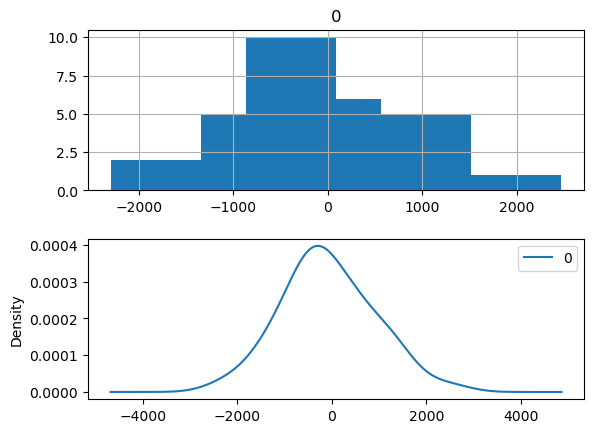

In [8]:
# plot
plt.figure();
plt.subplot(211);
residuals.hist(ax=plt.gca());
plt.subplot(212);
residuals.plot(kind='kde', ax=plt.gca());

## Residual ACF and PACF

Inspect the autocorrelation structure of the corrected residuals. No significant spikes beyond the confidence bands would indicate the model has captured the available signal and the residuals are consistent with white noise.

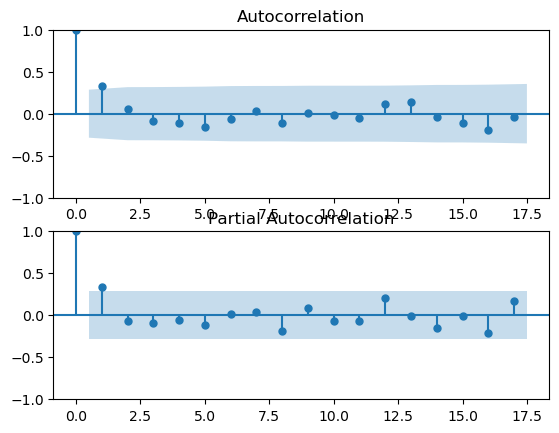

In [9]:
# plot
plt.figure();
plt.subplot(211);
plot_acf(residuals, ax=plt.gca());
plt.subplot(212);
plot_pacf(residuals, ax=plt.gca());

## Persist Model and Bias Constant

Fit the final model on the full training history (not the 50/50 train split). Serialise the `ExponentialSmoothing` results object to `models/hw_model.pkl` and save the bias scalar to `models/hw_bias.npy`. These two artefacts together constitute the complete deployable model.

In [10]:
# fit final model on full dataset and save
# bias = mean residual from the test walk-forward above
bias = residuals[0].mean()
final_model = ExponentialSmoothing(
    X,
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
)
final_fit = final_model.fit(optimized=True)
with open('models/hw_model.pkl', 'wb') as f:
    pickle.dump(final_fit, f)
np.save('models/hw_bias.npy', [bias])

## Load Model and Generate Next-Step Forecast

Demonstrate the complete prediction pipeline using the saved artefacts: load the model and bias constant, produce a one-step-ahead forecast, and apply the bias correction. This is the exact code path that would be used in production.

In [11]:
with open('models/hw_model.pkl', 'rb') as f:
    final_fit = pickle.load(f)
bias = float(np.load('models/hw_bias.npy')[0])
yhat = bias + final_fit.forecast(1)[0]
print('Predicted: %.3f' % yhat)

Predicted: 6808.785


## Load Held-Out Validation Data

Load the 12-month validation set that was held back at the very start of the project. This is the first and only time validation data is used — it has had no influence on any modelling decisions.

In [12]:
X = series.values.astype('float64')
history = [x for x in X]
validation = pd.read_csv('data/validation.csv', index_col=0, parse_dates=True).iloc[:, 0]
y = validation.values.astype('float64')
validation.head()

Month
1971-10-01     6981
1971-11-01     9851
1971-12-01    12670
1972-01-01     4348
1972-02-01     3564
Name: Sales, dtype: int64

## First Validation Forecast (from Saved Model)

Generate the first validation forecast using the persisted model object, then append the true observation to history. Subsequent forecasts re-fit the model to keep it current, matching the walk-forward protocol used during development.

In [13]:
predictions = list()
yhat = bias + final_fit.forecast(1)[0]
predictions.append(yhat)
history.append(y[0])
print('>Predicted=%.3f, Expected=%.3f' % (yhat, y[0]))

>Predicted=6808.785, Expected=6981.000


## Rolling Validation Forecasts

Walk forward through the remaining 11 validation observations, re-fitting the model at each step with the full updated history and applying the bias correction to every forecast.

In [14]:
# rolling forecasts
for i in range(1, len(y)):
    model = ExponentialSmoothing(
        history,
        trend='add',
        damped_trend=True,
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    model_fit = model.fit(optimized=True)
    if not is_hw_fit_valid(model_fit):
        raise RuntimeError(
            f"Holt-Winters did not produce valid smoothing parameters at validation step {i}: "
            f"{model_fit.params}"
        )
    yhat = bias + model_fit.forecast(1)[0]
    predictions.append(yhat)
    obs = y[i]
    history.append(obs)
    print('>Predicted=%.3f, Expected=%.3f' % (yhat, obs))

>Predicted=10294.313, Expected=9851.000
>Predicted=13269.030, Expected=12670.000
>Predicted=3830.089, Expected=4348.000
>Predicted=3397.555, Expected=3564.000
>Predicted=4301.354, Expected=4577.000
>Predicted=4634.667, Expected=4788.000
>Predicted=4735.443, Expected=4618.000
>Predicted=4845.471, Expected=5312.000
>Predicted=4632.731, Expected=4298.000
>Predicted=1882.551, Expected=1413.000
>Predicted=5847.147, Expected=5877.000


## Final Validation Performance

Compute and report the RMSE on the held-out validation set — this is the definitive measure of out-of-sample model performance. Plot the actual validation values against the bias-corrected predictions to visually assess forecast quality across the full validation horizon.

RMSE: 358.853


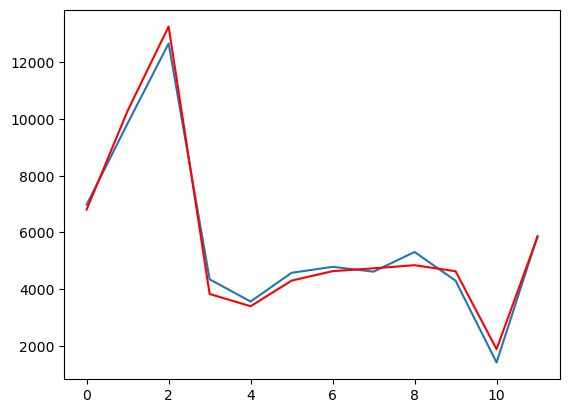

In [15]:
# report performance
rmse = sqrt(mean_squared_error(y, predictions))
print('RMSE: %.3f' % rmse)
plt.plot(y);
plt.plot(predictions, color='red');